In [5]:
# Library Imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import glob
import my_functions as mf
from scipy.optimize import curve_fit
from scipy.fftpack import fft, ifft, fftfreq
from scipy.special import voigt_profile
from scipy.signal import convolve
import re
import importlib
importlib.reload(mf)
from collections import defaultdict

In [6]:
## Data Paths
data_coherence_time_24mT_path = "data_optics/data_fergus/2025-05-01-ErYSO echoes/ErYSO echoes/24mT/"


## 24 mT ## 

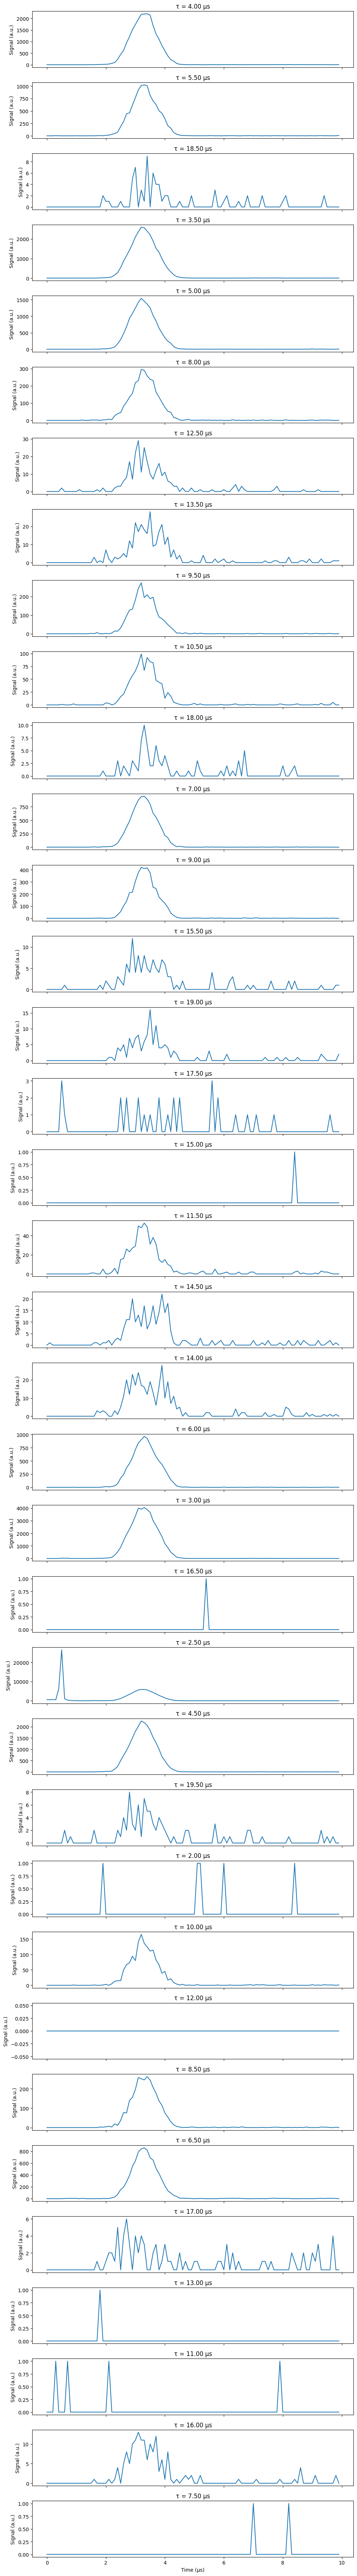

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd

# Collect and sort file paths
data_files = sorted(glob.glob(data_coherence_time_24mT_path + "*"))

# Store τ, time, and signal arrays
echo_data_list = []

# Plot setup
fig, axs = plt.subplots(len(data_files), 1, figsize=(10, len(data_files)*2), sharex=True)
if len(data_files) == 1:
    axs = [axs]  # ensure it's iterable

for i, file in enumerate(data_files):
    # Load time and signal (2 rows: time, signal)
    data = np.genfromtxt(file, delimiter=",")
    time = data[0] * 1e6  # convert to µs
    signal = data[1]

    # Extract τ from filename
    try:
        tau_str = os.path.basename(file).split("_tau")[1].split("_")[0]
        tau = float(tau_str)
    except Exception as e:
        print(f"⚠️ Could not parse τ from: {file}")
        tau = np.nan

    # Save in list
    echo_data_list.append({
        "tau": tau,
        "time": time,
        "signal": signal
    })

    # Plot
    ax = axs[i]
    ax.plot(time, signal)
    ax.set_ylabel("Signal (a.u.)")
    ax.set_title(f"τ = {tau:.2f} µs" if not np.isnan(tau) else "τ = ?")

axs[-1].set_xlabel("Time (µs)")
plt.tight_layout()

# Create DataFrame (no filename)
echo_df = pd.DataFrame(echo_data_list)



<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zj/k61bftd91r1cdpjh8_mkq7nm0000gn/T/ipykernel_16989/1747039630.py:61: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(tau_fit, np.log(fit_curve), '-', label=fr"Fit: $A_0 e^{{-4\tau/T_2}}$" + f"\n$T_2 = {T2_fit:.2f} \pm {T2_std:.2f}$ µs")


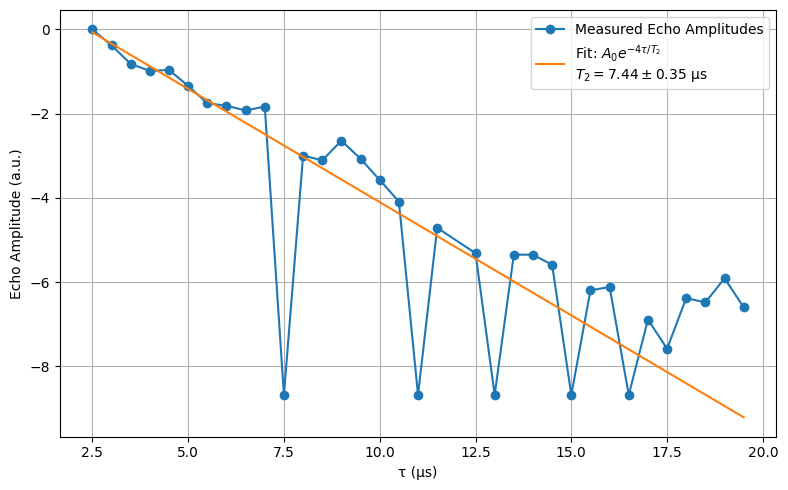

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Define exponential decay model ---
def echo_decay(tau, A0, T2):
    return A0 * np.exp(-4 * tau / T2)

# --- Extract max signal in each trace ---
amplitudes = []
taus_valid = []

for _, row in echo_df.iterrows():
    tau = row["tau"]
    signal = row["signal"]
    time = row["time"]

    if np.isnan(tau):
        continue

    if tau == 2.5:
        mask = (time > 1.5)
        echo_amp = np.max(signal[mask])
    else:
        echo_amp = np.max(signal)

    if tau == 2.0:
        continue

    amplitudes.append(echo_amp)
    taus_valid.append(tau)

# --- Convert and sort ---
taus_valid = np.array(taus_valid)
amplitudes = np.array(amplitudes)

sorted_indices = np.argsort(taus_valid)
taus_sorted = taus_valid[sorted_indices]
amplitudes_sorted = amplitudes[sorted_indices]

mask = np.isfinite(amplitudes_sorted) & (amplitudes_sorted > 0)
taus_sorted = taus_sorted[mask]
amplitudes_sorted = amplitudes_sorted[mask]
amplitudes_sorted_norm = amplitudes_sorted/np.max(amplitudes_sorted)

# amplitudes_sorted_log = np.log(amplitudes_sorted)
# amplitudes_sorted_norm_log = amplitudes_sorted_log/np.max(amplitudes_sorted_log)

# --- Fit to exponential decay model ---
popt, pcov = curve_fit(echo_decay, taus_sorted, amplitudes_sorted_norm, p0=(np.max(amplitudes_sorted_norm), 100))
A0_fit, T2_fit = popt
A0_std, T2_std = np.sqrt(np.diag(pcov))  # standard errors from covariance matrix

# --- Generate fit curve ---
tau_fit = np.linspace(min(taus_sorted), max(taus_sorted), 300)
fit_curve = echo_decay(tau_fit, *popt)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(taus_sorted,np.log(amplitudes_sorted_norm), 'o-', label="Measured Echo Amplitudes")
plt.plot(tau_fit, np.log(fit_curve), '-', label=fr"Fit: $A_0 e^{{-4\tau/T_2}}$" + f"\n$T_2 = {T2_fit:.2f} \pm {T2_std:.2f}$ µs")
plt.xlabel("τ (µs)")
plt.ylabel("Echo Amplitude (a.u.)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# # --- Linear fit in log space using polyfit ---
# slope, intercept = np.polyfit(taus_sorted, amplitudes_sorted_norm_log, deg=1)
# T2_linfit = -4 / slope
# A0_linfit = np.exp(intercept)
# log_fit_curve = np.exp(slope * tau_fit + intercept)

# # --- Add to plot ---
# plt.figure(figsize=(8, 5))
# plt.plot(taus_sorted, amplitudes_sorted_norm_log, 'o-', label="Measured Echo Amplitudes")
# plt.plot(tau_fit, log_fit_curve, '--', label=fr"Linear Fit (log-space): $T_2 = {T2_linfit:.2f}$ µs")
# plt.xlabel("τ (µs)")
# plt.ylabel("Echo Amplitude (a.u.)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()



## Overnight Sweep ##


In [9]:
import os
import glob
import numpy as np
import pandas as pd

# --- Step 1: Collect file paths ---
data_file_folders_all = []
data_files_all = []
data_folder_path = "data_optics/data_fergus/2025-05-01-ErYSO echoes/ErYSO echoes/overnight/"
data_folders = sorted(glob.glob(data_folder_path + "*"))

for folder_path in data_folders: 
    subfolders = sorted(glob.glob(folder_path + "*"))
    if subfolders:
        data_file_folders_all.append(subfolders[0] + "/")

for folder_path in data_file_folders_all: 
    data_files = sorted(glob.glob(folder_path + "*"))
    data_files_all.extend(data_files)  # flatten directly

# --- Step 2: Load data and extract metadata ---
echo_data_list = []

for file in data_files_all:
    try:
        data = np.genfromtxt(file, delimiter=",")
        time = data[0] * 1e6  # convert from s to µs
        signal = data[1]

        # Extract τ from filename
        tau_str = os.path.basename(file).split("_tau")[1].split("_")[0]
        tau = float(tau_str)

        # Extract B-field from folder or filename
        # Option A: from folder (recommended)
        parent_folder = os.path.basename(os.path.dirname(file))
        if "mT" in parent_folder:
            B_str = parent_folder.replace("mT", "").strip()
        else:
            # Option B: from filename
            B_str = os.path.basename(file).split("_")[-1].replace("mT.csv", "").strip()
        B_field = float(B_str)

        # Store in list
        echo_data_list.append({
            "tau": tau,
            "B": B_field,
            "time": time,
            "signal": signal
        })

    except Exception as e:
        print(f"⚠️ Could not parse file: {file}\n{e}")
        continue

# --- Step 3: Convert to DataFrame ---
echo_df = pd.DataFrame(echo_data_list)

# Preview
print(echo_df.head())


    tau    B                                               time  \
0  10.1  0.0  [0.0, 0.09999999999999999, 0.19999999999999998...   
1  19.6  0.0  [0.0, 0.09999999999999999, 0.19999999999999998...   
2  25.4  0.0  [0.0, 0.09999999999999999, 0.19999999999999998...   
3  23.2  0.0  [0.0, 0.09999999999999999, 0.19999999999999998...   
4  13.5  0.0  [0.0, 0.09999999999999999, 0.19999999999999998...   

                                              signal  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 1.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  


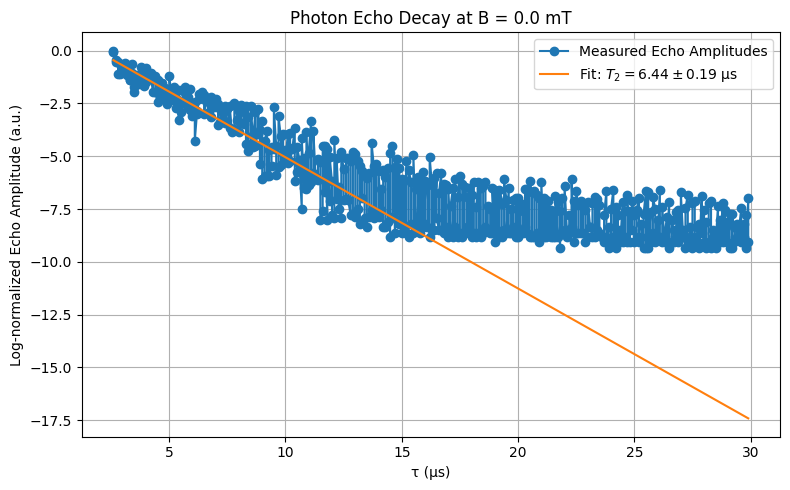

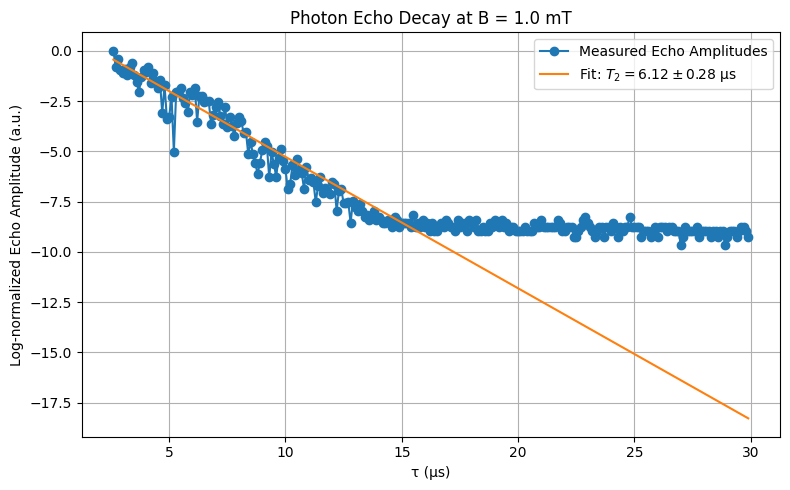

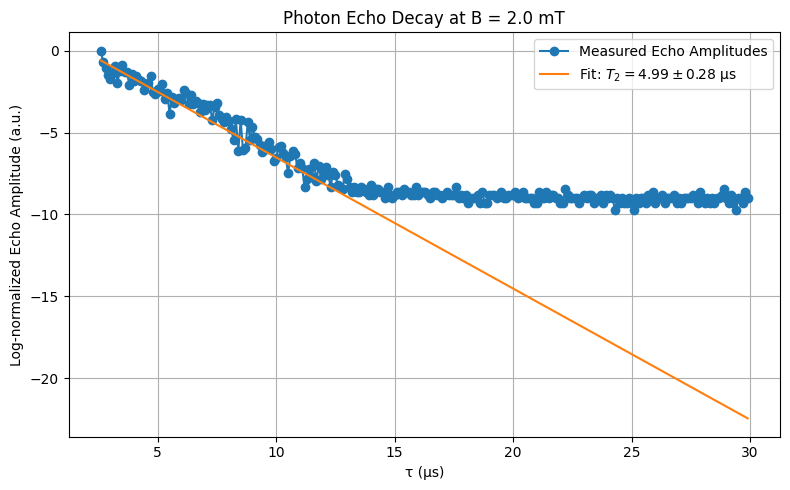

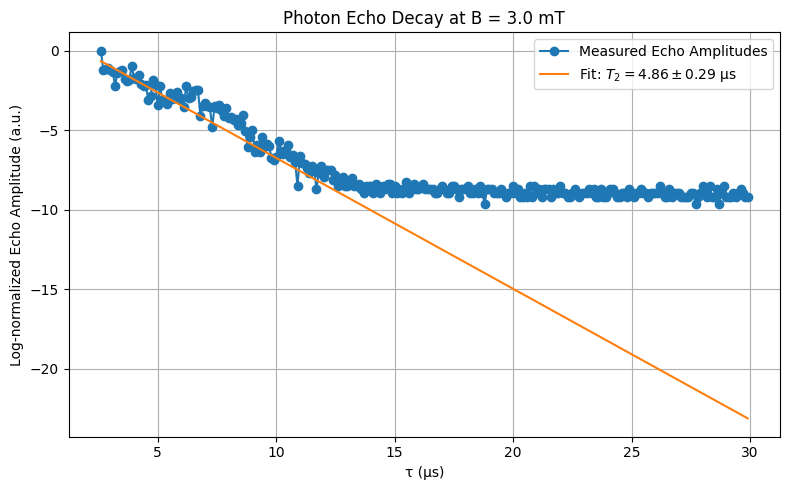

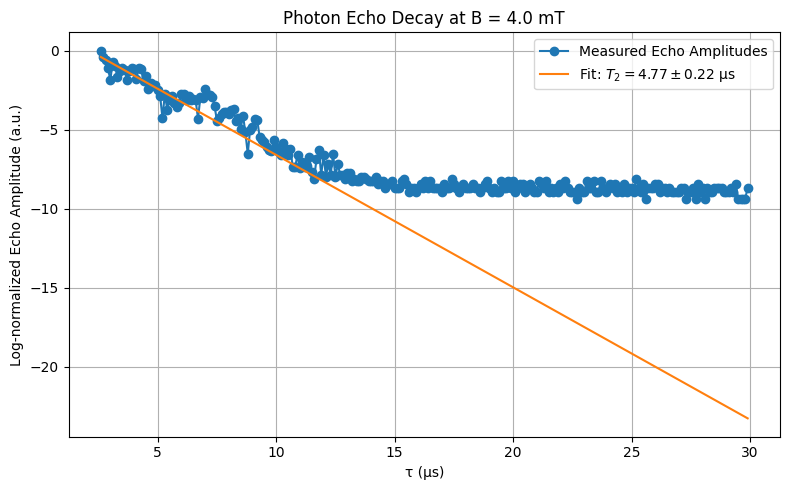

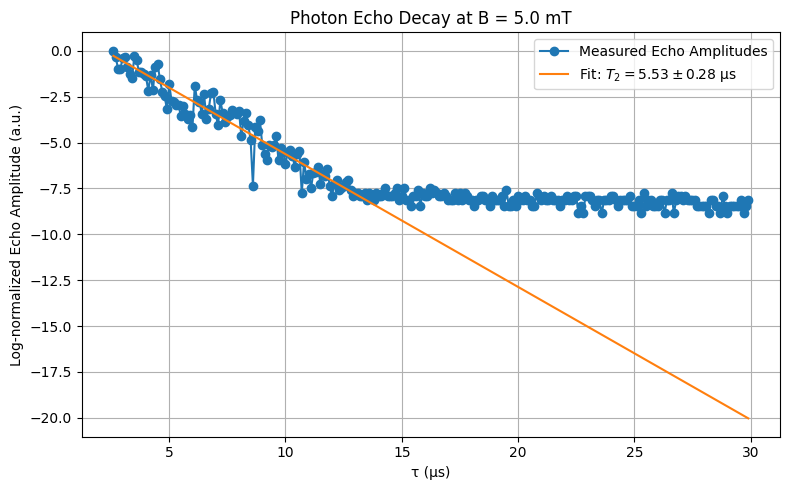

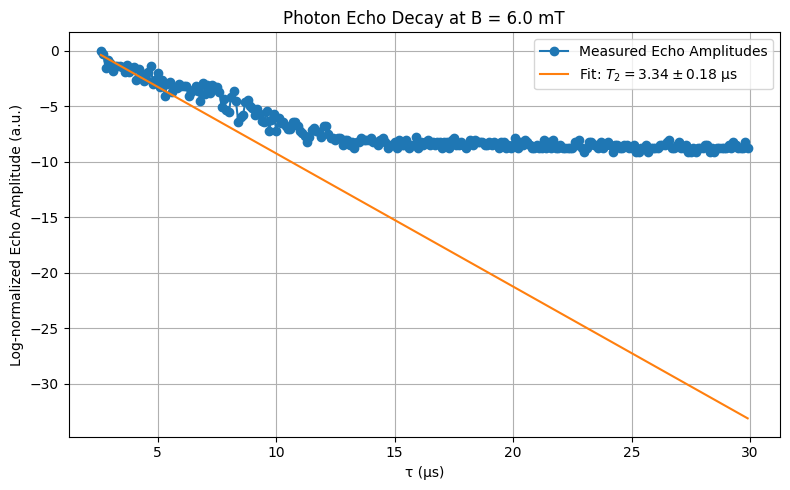

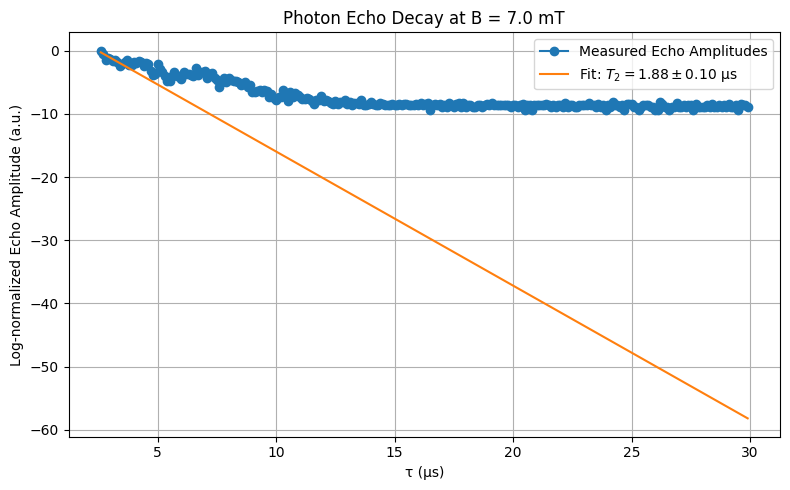

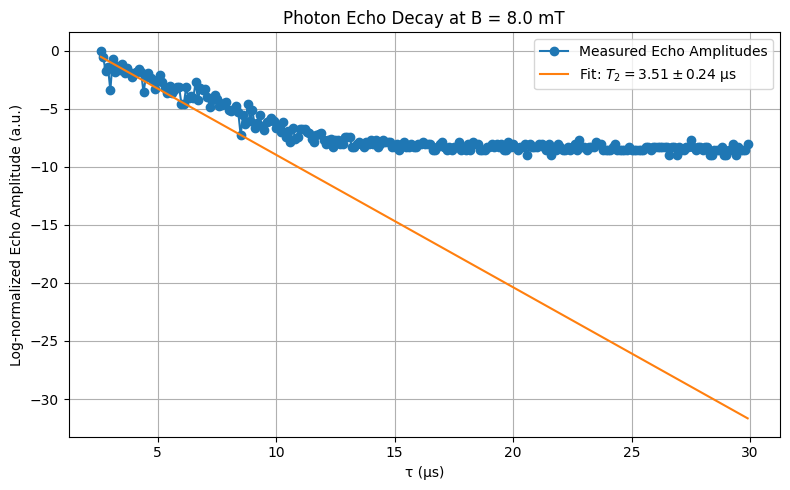

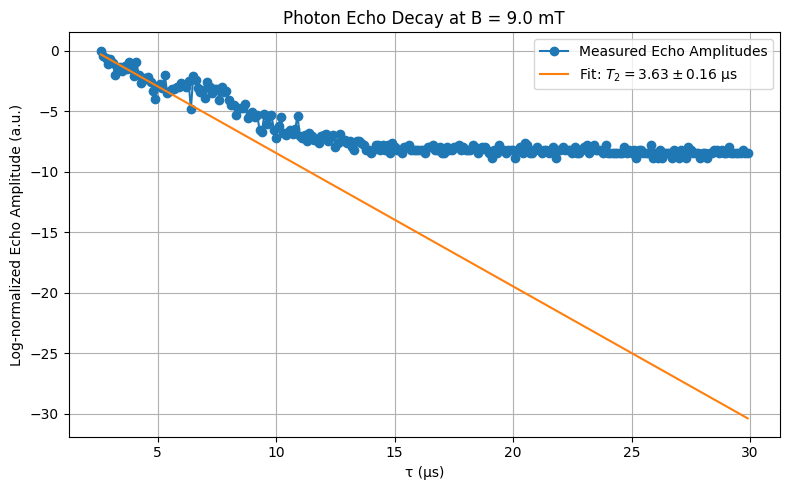

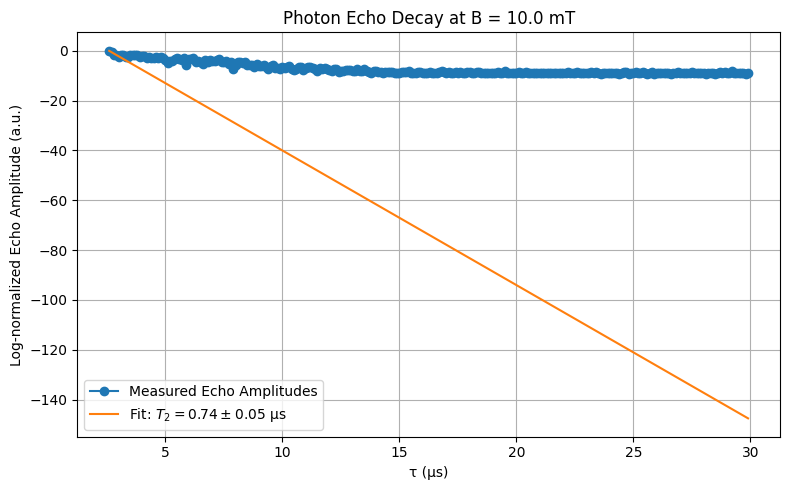

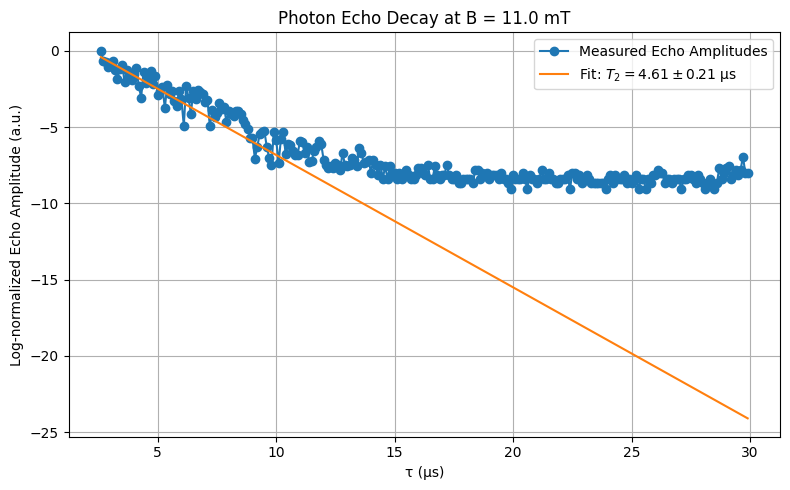

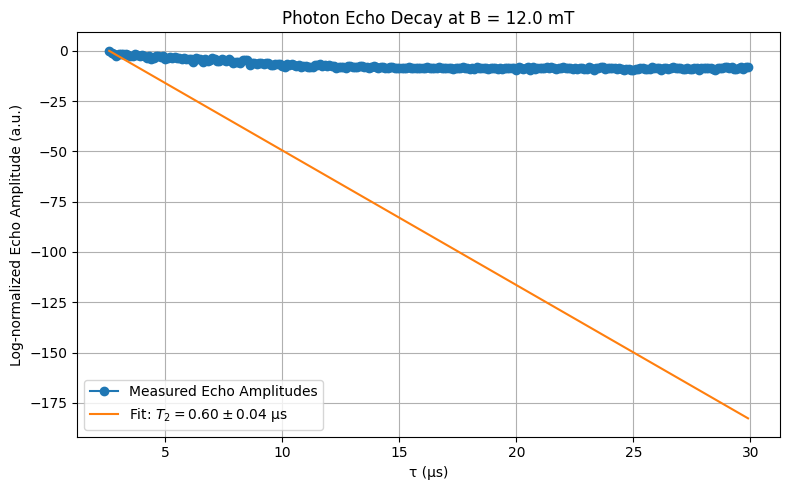

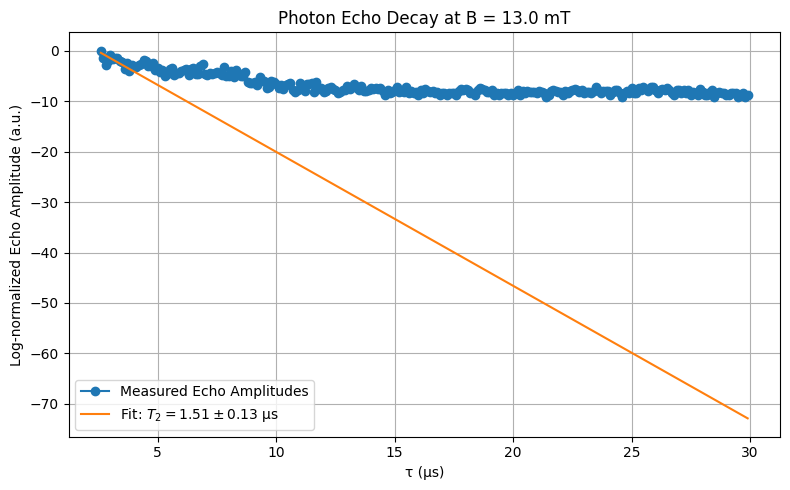

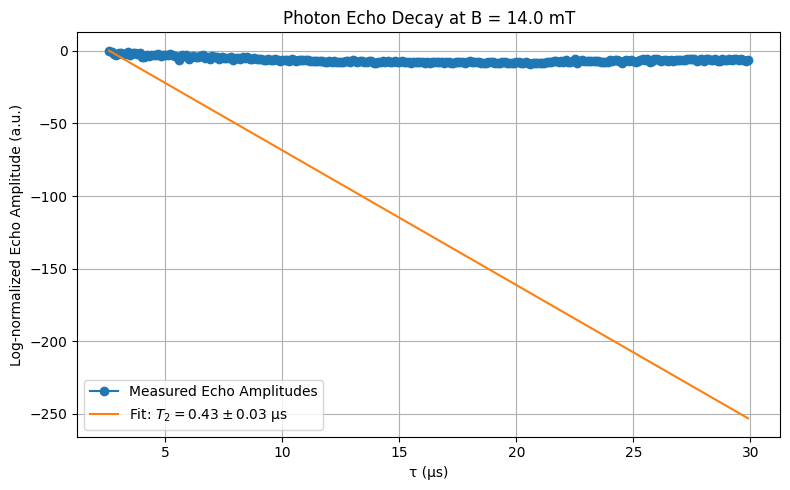

Fit failed for B = 15.0 mT: Optimal parameters not found: Number of calls to function has reached maxfev = 600.
Fit failed for B = 16.0 mT: Optimal parameters not found: Number of calls to function has reached maxfev = 600.


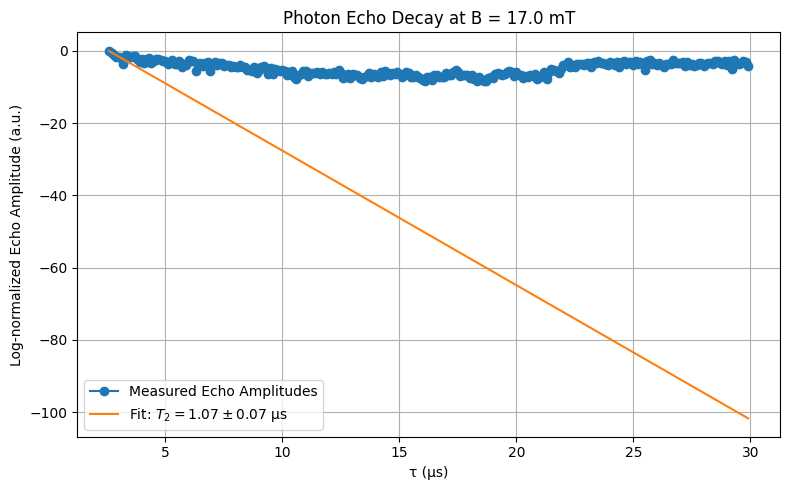

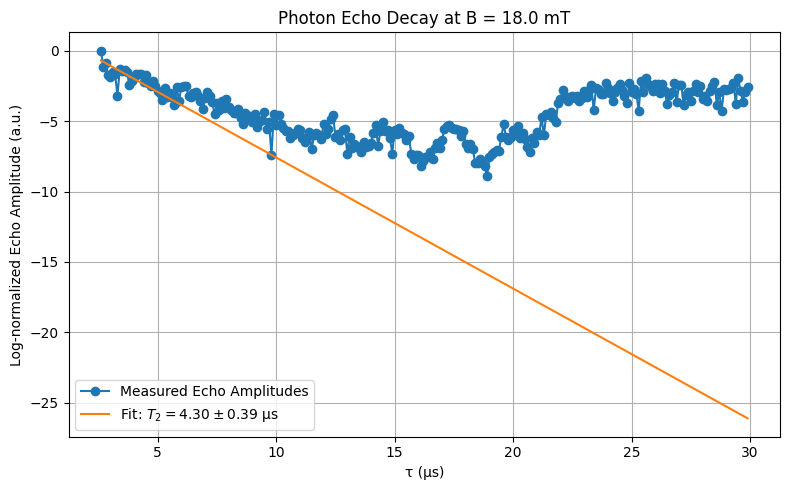

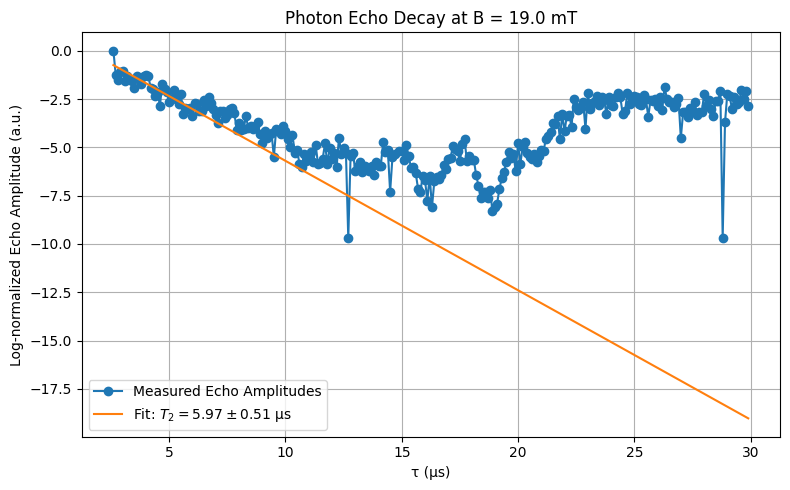

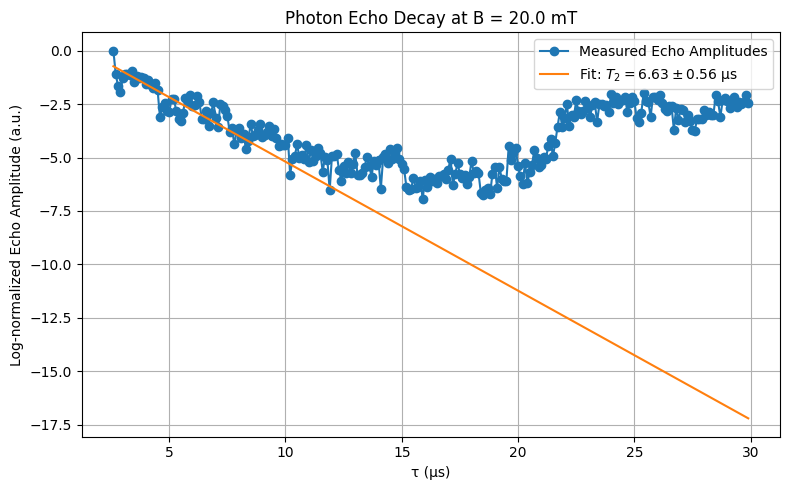

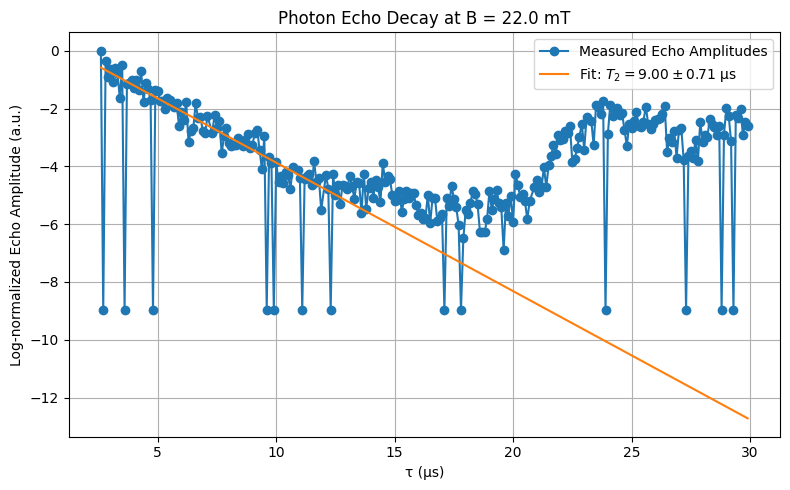

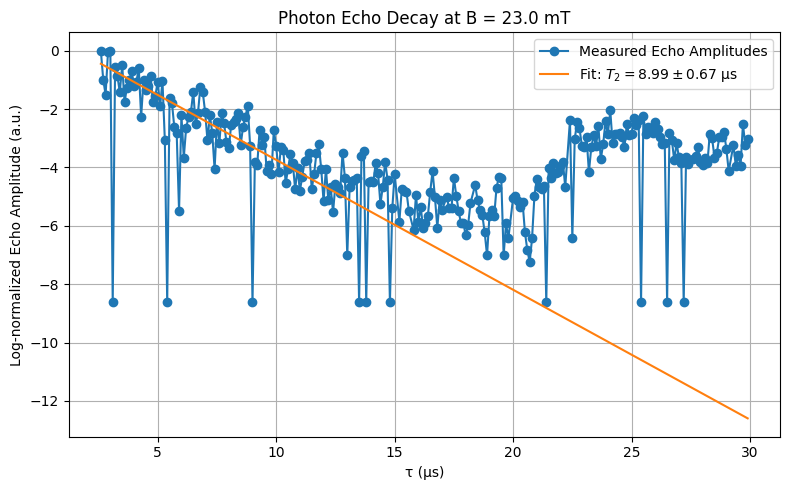

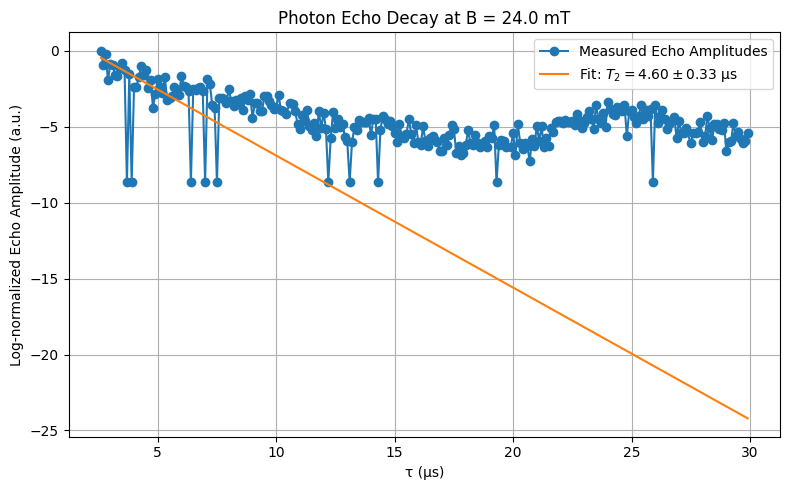

In [26]:
# --- Loop over magnetic fields ---
for B_val in sorted(echo_df["B"].unique()):
    sub_df = echo_df[echo_df["B"] == B_val]

    amplitudes = []
    taus_valid = []

    for _, row in sub_df.iterrows():
        tau = row["tau"]
        signal = row["signal"]
        time = row["time"]

        if np.isnan(tau):
            continue
        if tau <= 2.5:
            continue
        if tau == 2.5:
            mask = (time > 1.5)
            echo_amp = np.max(signal[mask])
        else:
            echo_amp = np.max(signal)



        amplitudes.append(echo_amp)
        taus_valid.append(tau)

    # --- Convert and sort ---
    taus_valid = np.array(taus_valid)
    amplitudes = np.array(amplitudes)

    sorted_indices = np.argsort(taus_valid)
    taus_sorted = taus_valid[sorted_indices]
    amplitudes_sorted = amplitudes[sorted_indices]

    mask = np.isfinite(amplitudes_sorted) & (amplitudes_sorted > 0)
    taus_sorted = taus_sorted[mask]
    amplitudes_sorted = amplitudes_sorted[mask]
    amplitudes_sorted_norm = amplitudes_sorted/np.max(amplitudes_sorted)
    # amplitudes_sorted_log = np.log(amplitudes_sorted)
    # amplitudes_sorted_norm_log = amplitudes_sorted_log / np.max(amplitudes_sorted_log)

    # --- Fit to exponential decay model ---
    try:
        popt, pcov = curve_fit(echo_decay, taus_sorted, amplitudes_sorted_norm, p0=(1.0, 100))
        A0_fit, T2_fit = popt
        A0_std, T2_std = np.sqrt(np.diag(pcov))
    except Exception as e:
        print(f"Fit failed for B = {B_val} mT: {e}")
        continue

    # --- Generate fit curve ---
    tau_fit = np.linspace(min(taus_sorted), max(taus_sorted), 300)
    fit_curve = echo_decay(tau_fit, *popt)

    #convert to log space
    amplitudes_sorted_log_norm = np.log(amplitudes_sorted_norm)
    fit_curve_log_norm = np.log(fit_curve)
    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.plot(taus_sorted,amplitudes_sorted_log_norm, 'o-', label="Measured Echo Amplitudes")
    plt.plot(tau_fit, fit_curve_log_norm, '-', label=fr"Fit: $T_2 = {T2_fit:.2f} \pm {T2_std:.2f}$ µs")
    plt.xlabel("τ (µs)")
    plt.ylabel("Log-normalized Echo Amplitude (a.u.)")
    plt.title(f"Photon Echo Decay at B = {B_val:.1f} mT")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


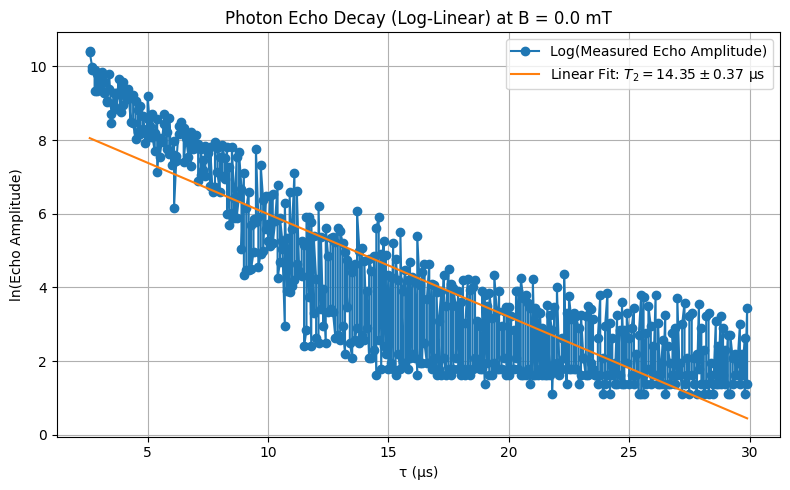

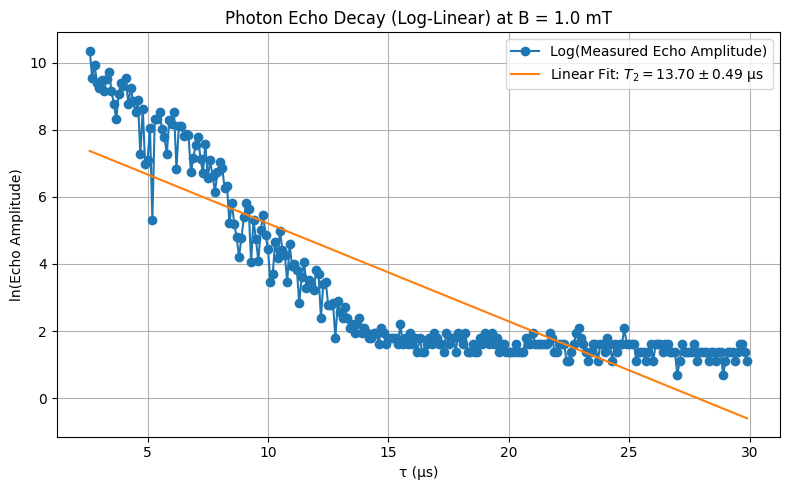

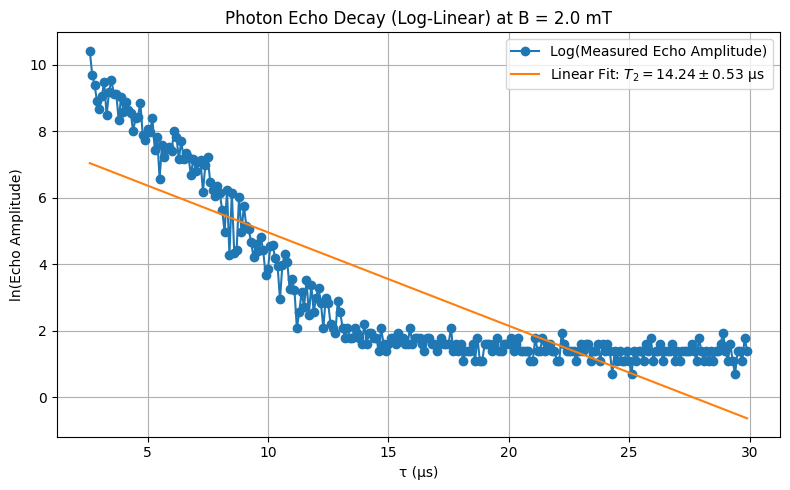

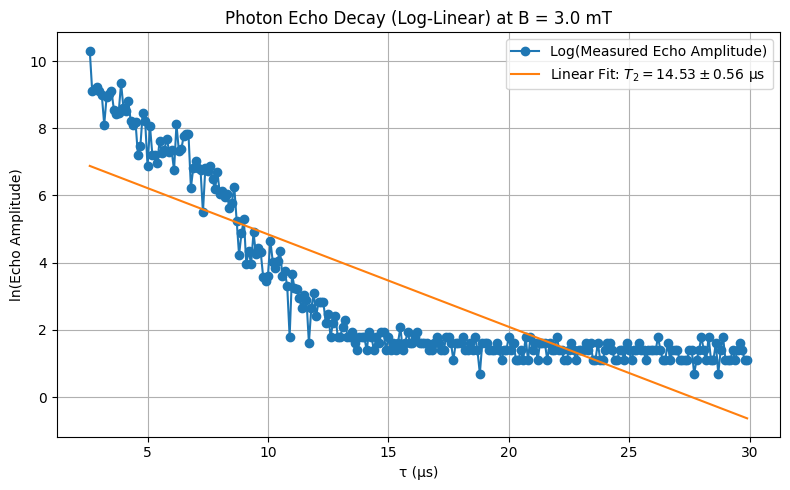

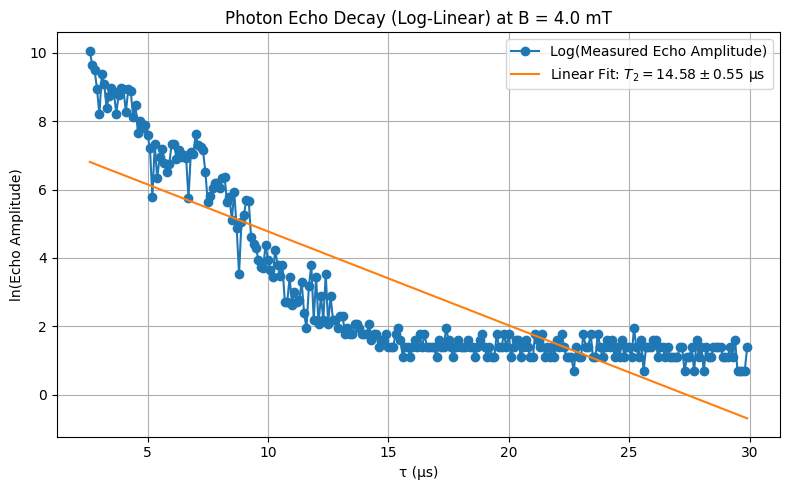

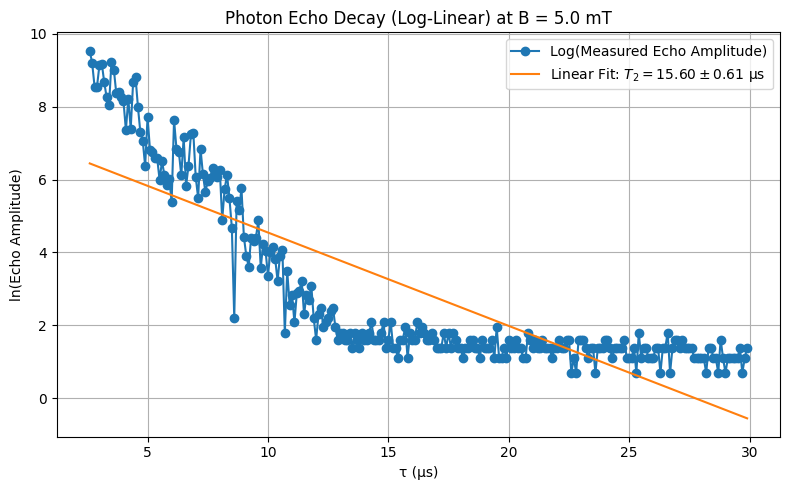

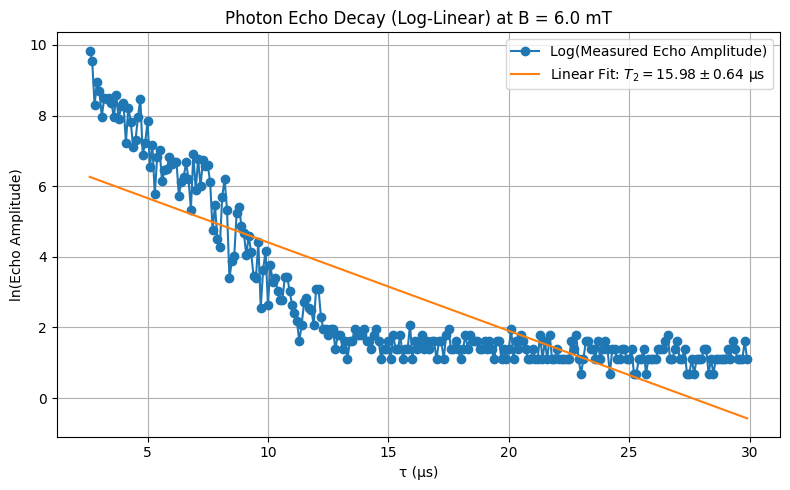

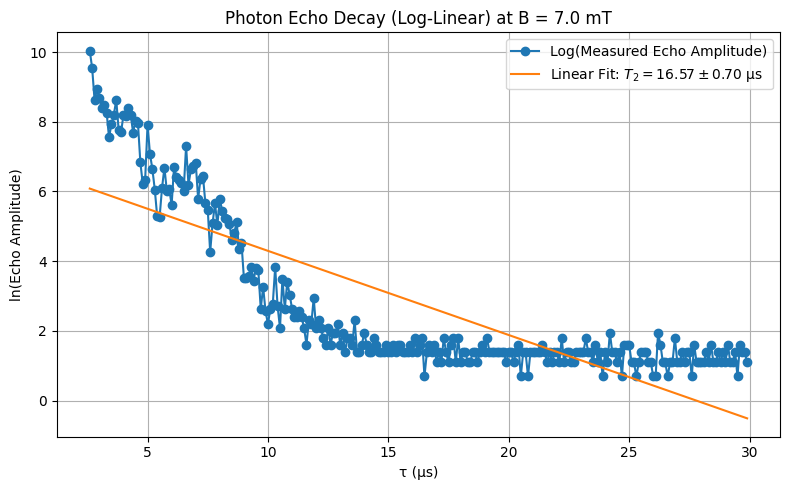

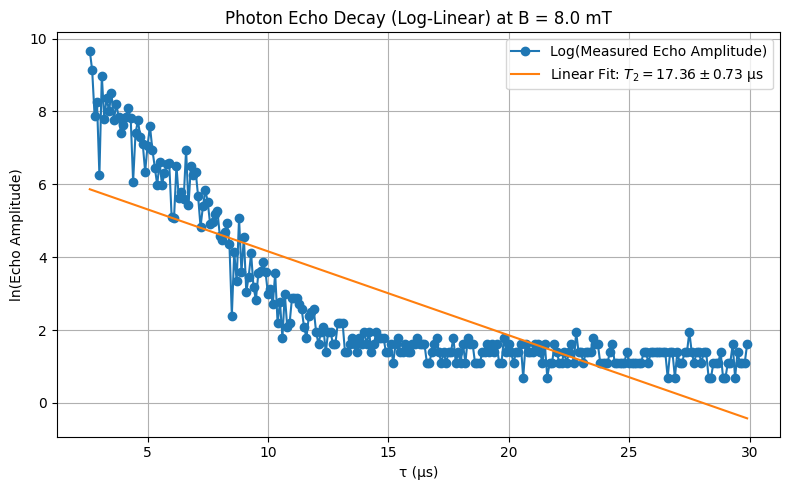

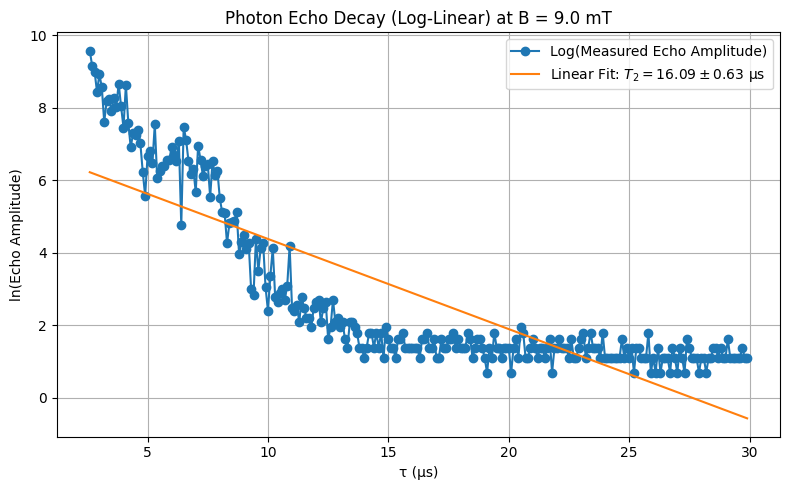

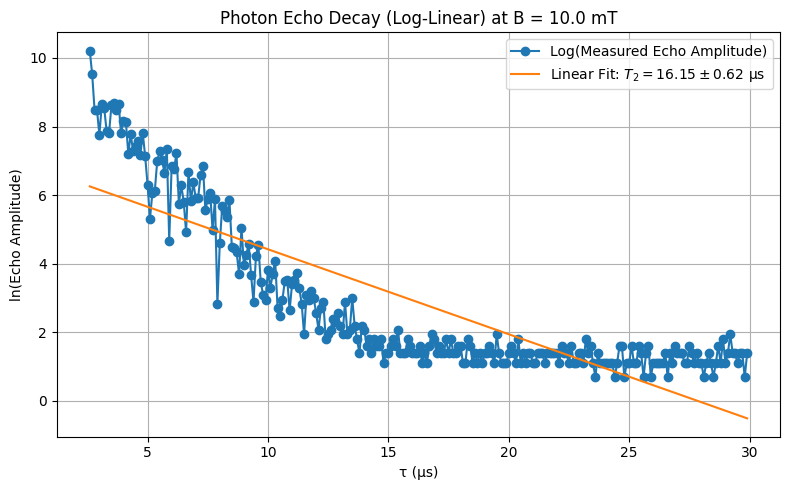

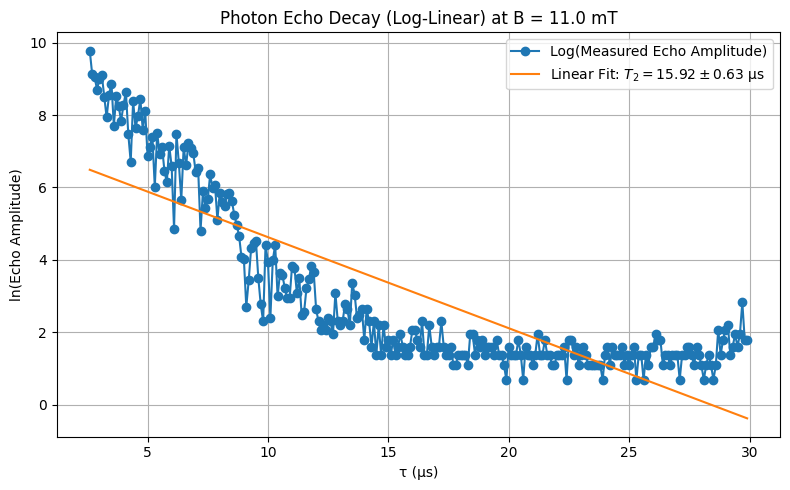

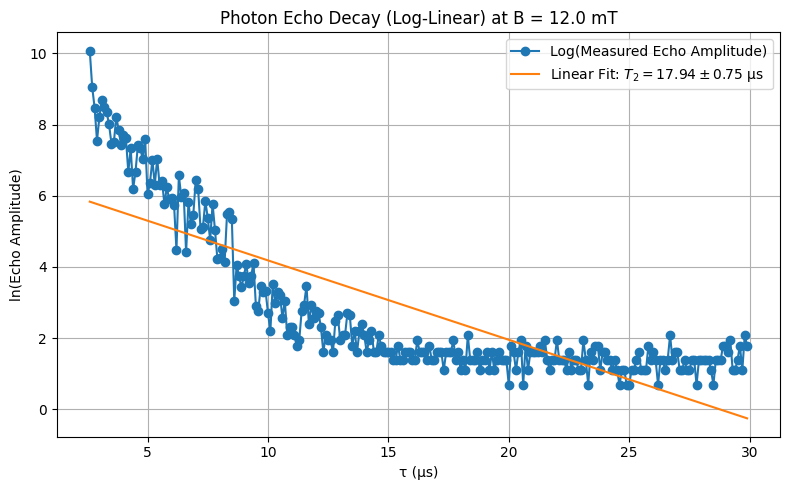

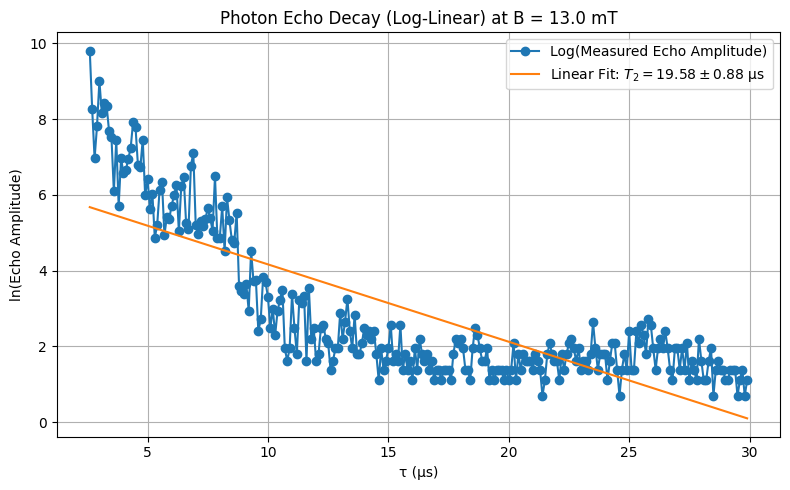

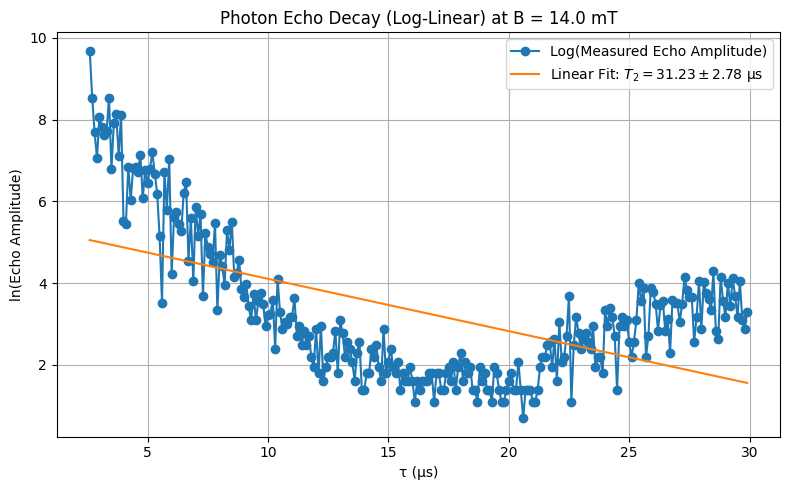

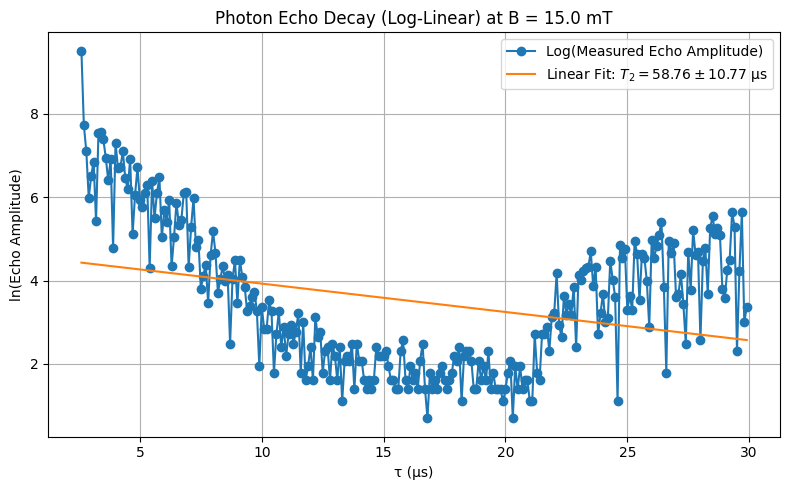

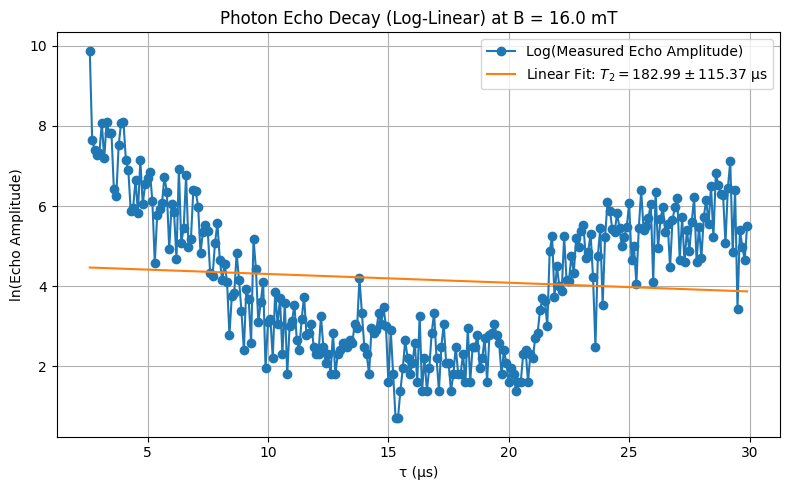

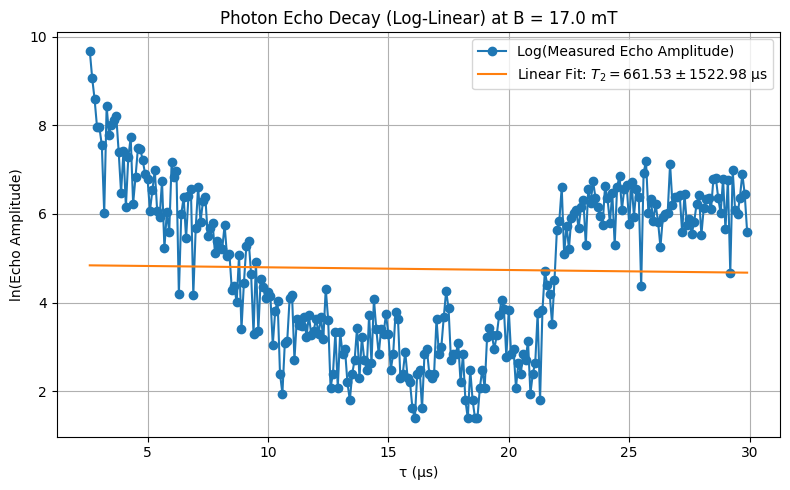

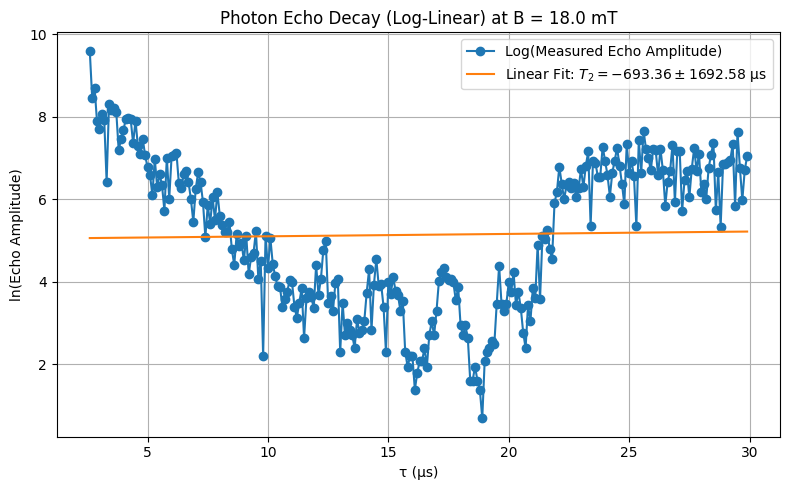

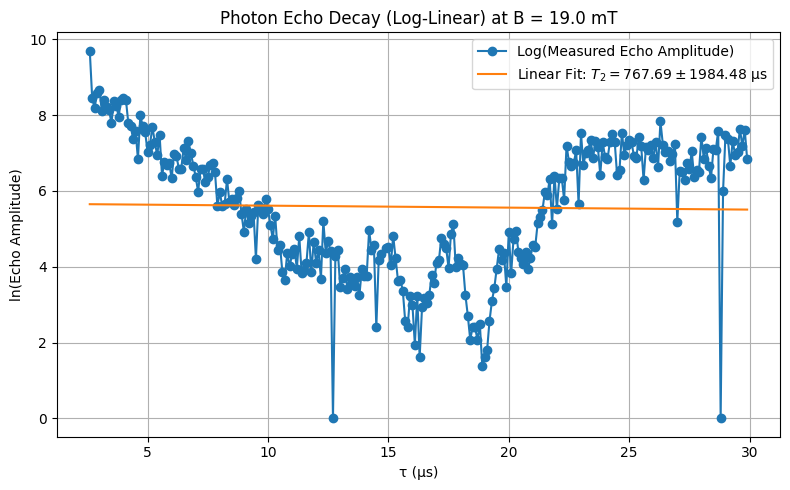

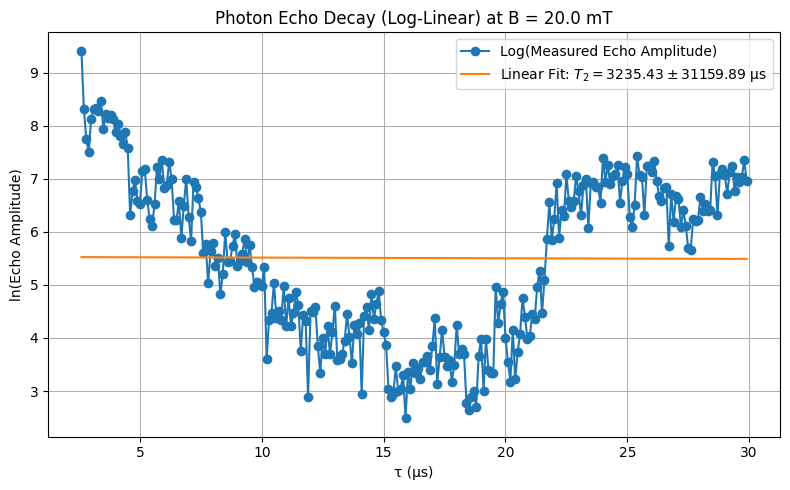

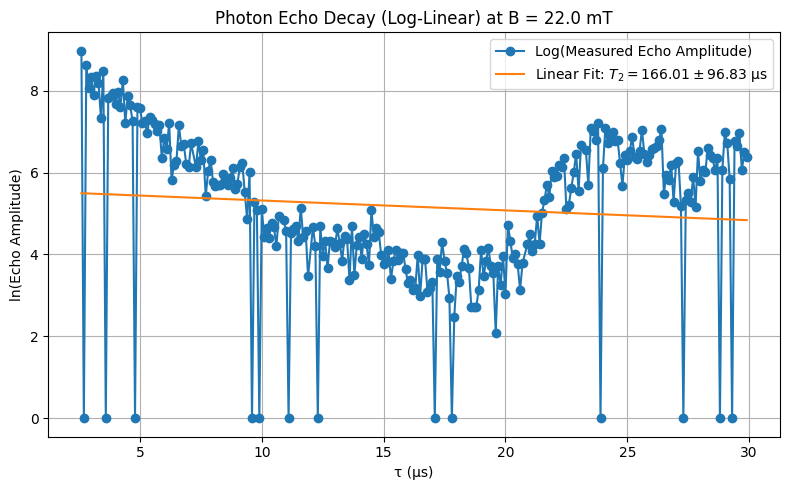

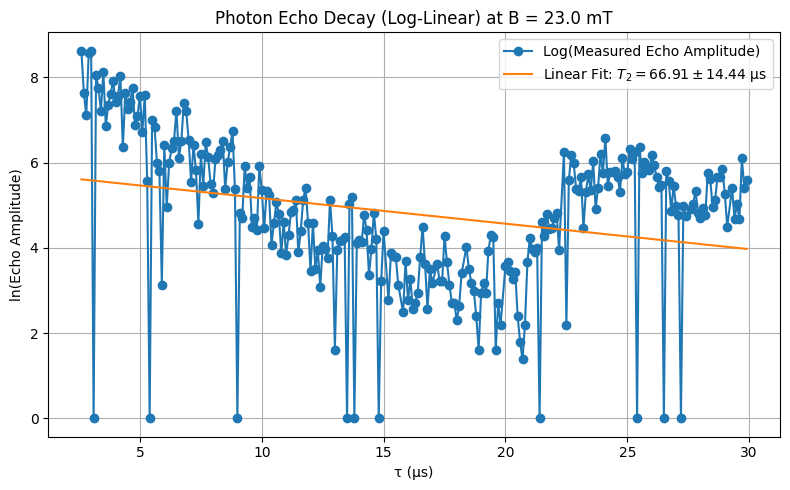

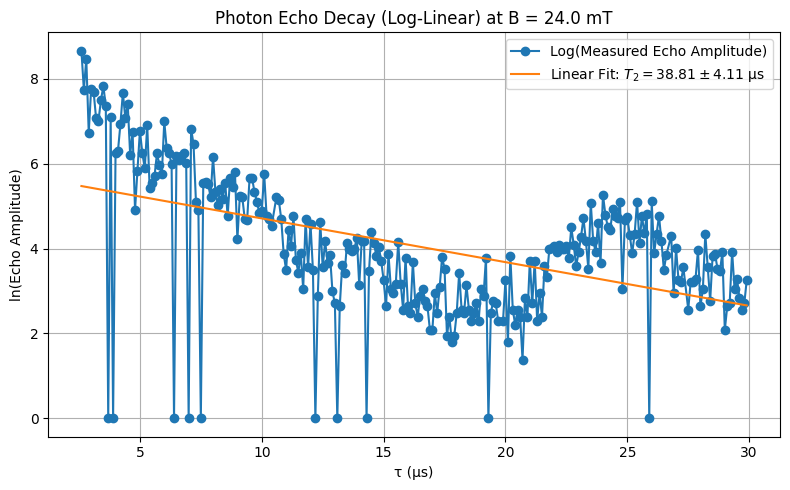

In [16]:
# --- Loop over magnetic fields ---
for B_val in sorted(echo_df["B"].unique()):
    sub_df = echo_df[echo_df["B"] == B_val]

    amplitudes = []
    taus_valid = []

    for _, row in sub_df.iterrows():
        tau = row["tau"]
        signal = row["signal"]
        time = row["time"]

        if np.isnan(tau):
            continue
        if tau <= 2.5:
            continue
        if tau == 2.5:
            mask = (time > 1.5)
            echo_amp = np.max(signal[mask])
        else:
            echo_amp = np.max(signal)

        amplitudes.append(echo_amp)
        taus_valid.append(tau)

    # --- Convert and sort ---
    taus_valid = np.array(taus_valid)
    amplitudes = np.array(amplitudes)

    sorted_indices = np.argsort(taus_valid)
    taus_sorted = taus_valid[sorted_indices]
    amplitudes_sorted = amplitudes[sorted_indices]

    mask = np.isfinite(amplitudes_sorted) & (amplitudes_sorted > 0)
    taus_sorted = taus_sorted[mask]
    amplitudes_sorted = amplitudes_sorted[mask]

    # Take log of amplitudes
    ln_amplitudes = np.log(amplitudes_sorted)

    # --- Fit to linear model: ln(A) = ln(A0) - 4*tau / T2 ---
    try:
        coeffs, cov = np.polyfit(taus_sorted, ln_amplitudes, deg=1, cov=True)
        slope, intercept = coeffs
        slope_err, intercept_err = np.sqrt(np.diag(cov))

        T2_fit = -4 / slope
        T2_std = 4 * slope_err / (slope ** 2)  # propagated error

    except Exception as e:
        print(f"Linear log-space fit failed for B = {B_val} mT: {e}")
        continue

    # --- Plot ---
    tau_fit = np.linspace(min(taus_sorted), max(taus_sorted), 300)
    ln_fit = slope * tau_fit + intercept

    plt.figure(figsize=(8, 5))
    plt.plot(taus_sorted, ln_amplitudes, 'o-', label="Log(Measured Echo Amplitude)")
    plt.plot(tau_fit, ln_fit, '-', label=fr"Linear Fit: $T_2 = {T2_fit:.2f} \pm {T2_std:.2f}$ µs")
    plt.xlabel("τ (µs)")
    plt.ylabel("ln(Echo Amplitude)")
    plt.title(f"Photon Echo Decay (Log-Linear) at B = {B_val:.1f} mT")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Rabi ##